### Machine learning and materials physics, 05-13-2026

You will follow a complete machine learning pipeline, from data preparation to model evaluation, using a materials science dataset. 

**Instructions:**
- Answer the questions in the cells provided for this purpose, using code if necessary.
- Online resources will be helpful! See e.g. the documentation of scikit-learn
- Questions are in <span style="color: blue;">blue</span>.
- The bonus part at the end of the notebook is not necessarily more complicated than the rest.

**Subject:**
We will be using a library (which you likely haven't used until now) called `matminer`. This is a library that allows to grab and exploit materials science datasets. After preparing this data, we will implement several machine learning models using the features of the `scikit-learn` library. Throughout the exam, we will use `matplotlib` to present results in graphical form.

The dataset we will use was the subject of a scientific article, which you can find in PDF format on Colab (`elastic_tensor.pdf`), or [online](https://www.nature.com/articles/sdata20159) (open-access). It is a dataset covering the elastic properties of many inorganic crystalline compounds (metals, oxides, alloys, etc.). These properties were not measured experimentally but were calculated using quantum chemistry methods.

---

### **Part 1: Data Preparation and Exploration**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matminer.datasets import load_dataset
from matminer.featurizers.composition import ElementProperty
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

from sklearn.model_selection import KFold, cross_val_score

Here we load the "elastic_tensor_2015" dataset, which was previously downloaded, into a `pandas` DataFrame. We also remove some columns of data that we will not need.

In [2]:
df = pd.read_pickle("elastic_tensor.pkl")

unwanted_columns = ["volume", "nsites", "compliance_tensor", "elastic_tensor", 
                    "elastic_tensor_original", "K_Voigt", "G_Voigt", "K_Reuss", "G_Reuss"]
df = df.drop(unwanted_columns, axis=1)

<span style="color: blue;">**Question 1**: Display the first 5 rows, then a statistical summary (`.describe()`) of the DataFrame.</span>

In [3]:
df.head()

,material_id,formula,space_group,structure,elastic_anisotropy,G_VRH,K_VRH,poisson_ratio
0,mp-10003,Nb4CoSi,124,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",0.030688,97.141604,194.268884,0.285701
1,mp-10010,Al(CoSi)2,164,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",0.266910,96.252006,175.449907,0.268105
2,mp-10015,SiOs,221,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",0.756489,130.112955,295.077545,0.307780
3,mp-10021,Ga,63,"[[0. 1.09045794 0.84078375] Ga, [0. ...",2.376805,15.101901,49.130670,0.360593
4,mp-10025,SiRu2,62,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",0.196930,101.947798,256.768081,0.324682


In [4]:
df.describe()

,space_group,elastic_anisotropy,G_VRH,K_VRH,poisson_ratio
count,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000
mean,163.403895,2.145013,67.543145,136.259661,0.287401
std,65.040733,19.140097,44.579408,72.886978,0.062177
min,4.000000,0.000005,2.722175,6.476135,0.042582
25%,124.000000,0.145030,34.117959,76.435350,0.249159
50%,193.000000,0.355287,59.735163,130.382766,0.290198
75%,221.000000,0.923117,91.332142,189.574194,0.328808
max,229.000000,397.297866,522.921225,435.661487,0.467523


<span style="color: blue;">**Question 2**: How many data points are there? What is the dimensionality of this data?</span>

<span style="color: blue;">**Question 3**: Based on the article `elastic_tensor.pdf`, determine which column label corresponds to the shear modulus in our filtered DataFrame. What units are used?</span>

<span style="color: blue;">**Question 4**: Prepare four graphs below representing the distributions of the columns `elastic_anisotropy`, `G_VRH`, `K_VRH`, and `poisson_ratio` using histograms. For example, you could use the `plt.hist()` method from `matplotlib`. For the first quantity, use a logarithmic scale for the y-axis.</span>

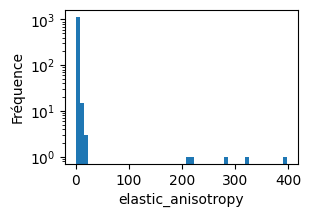

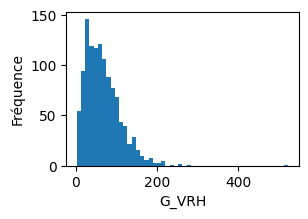

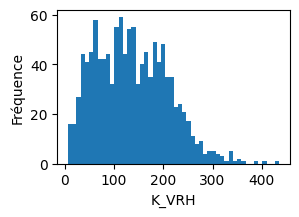

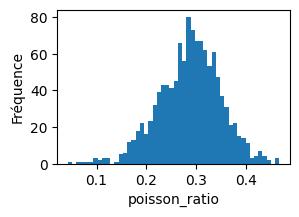

In [5]:
plt.rcParams['figure.figsize'] = [3, 2]

plt.hist(df['elastic_anisotropy'], bins=50, log=True)
plt.xlabel("elastic_anisotropy")
plt.ylabel("Fréquence")
plt.show()

plt.hist(df['G_VRH'], bins=50)
plt.xlabel("G_VRH")
plt.ylabel("Fréquence")
plt.show()

plt.hist(df['K_VRH'], bins=50)
plt.xlabel("K_VRH")
plt.ylabel("Fréquence")
plt.show()

plt.hist(df['poisson_ratio'], bins=50)
plt.xlabel("poisson_ratio")
plt.ylabel("Fréquence")
plt.show()

The "formula" column contains the chemical formula of the materials. We cannot use it directly in a machine learning model for regression, for example (as it is a text string); with `matminer`, we will generate new descriptors from this formula. This is done here in four steps: 
1) Convert the text string into a "composition" in the matminer format
2) Retrieve descriptors specific to this elemental composition, as well as
3) Oxidation state descriptors
4) Descriptors of the crystal structure of the materials, obtained from the density

In [6]:
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import CompositionToOxidComposition
from matminer.featurizers.composition import OxidationStates
from matminer.featurizers.structure import DensityFeatures

df = StrToComposition().featurize_dataframe(df, "formula")

ep_feat = ElementProperty.from_preset(preset_name="magpie", impute_nan=True)
df = ep_feat.featurize_dataframe(df, col_id="composition")

df = CompositionToOxidComposition().featurize_dataframe(df, "composition")

os_feat = OxidationStates()
df = os_feat.featurize_dataframe(df, "composition_oxid")

df_feat = DensityFeatures()
df = df_feat.featurize_dataframe(df, "structure")

StrToComposition:   0%|          | 0/1181 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/1181 [00:00<?, ?it/s]

CompositionToOxidComposition:   0%|          | 0/1181 [00:00<?, ?it/s]

OxidationStates:   0%|          | 0/1181 [00:00<?, ?it/s]

DensityFeatures:   0%|          | 0/1181 [00:00<?, ?it/s]

<span style="color: blue;">**Question 5** : What is the new dimensionality of the data?</span>

144 (obtained for instance via `df.describe()`). 

### **Part 2: A first linear model**

We will now try to predict the bulk modulus $K$, using the descriptors introduced previously. This modulus describes a material's resistance to isostatic compression: 

$$K = -V \frac{dP}{dV},$$ 

where $V$ is the initial volume of the material and $P$ is the pressure. 
Below, we prepare two variables, `y` and `X`, which correspond respectively to the bulk modulus and the set of descriptors with which we will attempt to predict it. `X` therefore forms a basis on which we will try to express `y`.

In [7]:
y = df['K_VRH'].values
excluded = ["G_VRH", "K_VRH", "elastic_anisotropy", "formula", "material_id", 
            "poisson_ratio", "structure", "composition", "composition_oxid"]
X = df.drop(excluded, axis=1)

print("There are {} descriptors:\n\n{}".format(X.shape[1], X.columns.values))

There are 140 descriptors:

['space_group' 'MagpieData minimum Number' 'MagpieData maximum Number'
 'MagpieData range Number' 'MagpieData mean Number'
 'MagpieData avg_dev Number' 'MagpieData mode Number'
 'MagpieData minimum MendeleevNumber' 'MagpieData maximum MendeleevNumber'
 'MagpieData range MendeleevNumber' 'MagpieData mean MendeleevNumber'
 'MagpieData avg_dev MendeleevNumber' 'MagpieData mode MendeleevNumber'
 'MagpieData minimum AtomicWeight' 'MagpieData maximum AtomicWeight'
 'MagpieData range AtomicWeight' 'MagpieData mean AtomicWeight'
 'MagpieData avg_dev AtomicWeight' 'MagpieData mode AtomicWeight'
 'MagpieData minimum MeltingT' 'MagpieData maximum MeltingT'
 'MagpieData range MeltingT' 'MagpieData mean MeltingT'
 'MagpieData avg_dev MeltingT' 'MagpieData mode MeltingT'
 'MagpieData minimum Column' 'MagpieData maximum Column'
 'MagpieData range Column' 'MagpieData mean Column'
 'MagpieData avg_dev Column' 'MagpieData mode Column'
 'MagpieData minimum Row' 'MagpieData max

<span style="color: blue;">**Question 6**: Prepare a linear regression model to estimate the bulk modulus from the descriptors listed previously. For example, you could use the `LinearRegression` class from `scikit-learn`. For now, do not split the data into training and test sets.</span>

In [8]:
lr = LinearRegression()

lr.fit(X, y)

LinearRegression()

<span style="color: blue;">**Question 7**: Report the value of the coefficient of determination ($R^2$), as well as the root-mean-square error (RMSE). These two quantities should be calculated on the entire dataset.</span>

In [9]:
print('Training R2 = ' + str(round(lr.score(X, y), 3)))
print('Training RMSE = %.3f' % np.sqrt(mean_squared_error(y_true=y, y_pred=lr.predict(X))))

Training R2 = 0.928
Training RMSE = 19.611


We now wish to perform a $k$-fold cross-validation.

<span style="color: blue;">**Question 8**: Perform this cross-validation with $k=10$ on our linear model. You could, for example, use a class already implemented in `scikit-learn`. You will report two scores: the $R^2$ and the RMSE, obtained by averaging across the distribution of folds. Comment on their values compared to what you obtained earlier by training the model with all the data.</span>

In [10]:
# compute cross validation scores for the linear model
crossvalidation = KFold(n_splits=10, shuffle=True, random_state=1)
r2_scores = cross_val_score(lr, X, y, scoring='r2', cv=crossvalidation, n_jobs=-1)
scores = cross_val_score(lr, X, y, scoring='neg_mean_squared_error', cv=crossvalidation, n_jobs=-1)
rmse_scores = [np.sqrt(abs(s)) for s in scores]

print('Cross-validation results:')
print('Folds: %i, mean R2: %.3f' % (len(scores), np.mean(np.abs(r2_scores))))
print('Folds: %i, mean RMSE: %.3f' % (len(scores), np.mean(rmse_scores)))

Cross-validation results:
Folds: 10, mean R2: 0.902
Folds: 10, mean RMSE: 22.453


<span style="color: blue;">**Question 9**: Now report the standard deviations of the $R^2$ and RMSE distributions across all folds.</span>

In [11]:
print(np.std(np.abs(r2_scores)))
print(np.std(rmse_scores))

0.034503178776429964
4.087597572971764


### **Part 3: A Random forest model**

We now wish to implement a more complex model: a [random forest](https://en.wikipedia.org/wiki/Random_forest), also known as a forest of decision trees. The goal is to determine if we can obtain a more performant or robust model than the previous linear regression.

![title](img/random_forest.png)

<span style="color: blue;">**Question 10**: Implement a random forest model (**regression!**) composed of 50 decision trees. At this stage, use all the data for training.</span>

In [12]:
rf = RandomForestRegressor(n_estimators=50, random_state=3)

rf.fit(X, y)

RandomForestRegressor(n_estimators=50, random_state=3)

<span style="color: blue;">**Question 11**: Report the $R^2$ and the RMSE for this model. Have we obtained a more accurate model than the previous linear regression?</span>

In [13]:
print('training R2 = ' + str(round(rf.score(X, y), 3)))
print('training RMSE = %.3f' % np.sqrt(mean_squared_error(y_true=y, y_pred=rf.predict(X))))

training R2 = 0.99
training RMSE = 7.369


<span style="color: blue;">**Question 12**: Perform a $k$-fold cross-validation on this model, with $k=10$.</span>

In [14]:
crossvalidation = KFold(n_splits=10, shuffle=True, random_state=4)
r2_scores = cross_val_score(rf, X, y, scoring='r2', cv=crossvalidation, n_jobs=-1)
scores = cross_val_score(rf, X, y, scoring='neg_mean_squared_error', cv=crossvalidation, n_jobs=-1)
rmse_scores = [np.sqrt(abs(s)) for s in scores]

<span style="color: blue;">**Question 13**: Report the means and standard deviations of the $R^2$ and RMSE across the fold distributions. By comparing these values to those obtained with the linear model, can we say that we have obtained a model that is more or less accurate, and more or less robust?</span>

In [15]:
print('Cross-validation results:')
print('Folds: %i, mean R2: %.3f' % (len(scores), np.mean(np.abs(r2_scores))))
print('Folds: %i, mean RMSE: %.3f' % (len(scores), np.mean(rmse_scores)))

print(np.abs(r2_scores))
print(np.std(np.abs(rmse_scores)))
print(rmse_scores)

Cross-validation results:
Folds: 10, mean R2: 0.920
Folds: 10, mean RMSE: 20.034
[0.93638032 0.95526665 0.91421463 0.95979229 0.83749331 0.95816106
 0.93519352 0.88707742 0.88211423 0.9387907 ]
5.7336795760247545
[17.9388459278615, 15.523069886947193, 20.822821816779, 15.093233992554168, 33.91424463454015, 13.648393268287709, 19.49151280418303, 22.253145371829024, 25.24847902597232, 16.41013574415662]


<span style="color: blue;">**Question 14**: Now train a single random forest model, this time with a data split into a training set (80%) and a test set (20%). For example, you could use the `train_test_split()` method from `scikit-learn`. Once the model is trained, prepare a graph with the reference bulk modulus on the $x$-axis and the model's prediction on the $y$-axis. Present the training and validation data using different colors. Print also the training and test set error metrics. </span>

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

rf = RandomForestRegressor(n_estimators=50, random_state=3)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

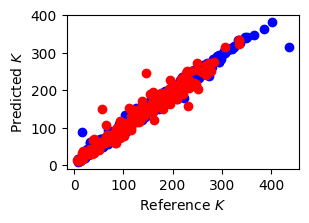

In [17]:
plt.scatter(y_train, y_train_pred, c='blue', label='train')
plt.scatter(y_test, y_test_pred, c='red', label='test')

plt.xlabel(r'Reference $K$')
plt.ylabel(r'Predicted $K$')

plt.show()

In [18]:
print('Training R2 = ' + str(round(rf.score(X_train, y_train), 3)))
print('Training RMSE = %.3f' % np.sqrt(mean_squared_error(y_true=y_train, y_pred=rf.predict(X_train))))
print('Test R2 = ' + str(round(rf.score(X_test, y_test), 3)))
print('Test RMSE = %.3f' % np.sqrt(mean_squared_error(y_true=y_test, y_pred=rf.predict(X_test))))

Training R2 = 0.988
Training RMSE = 8.184
Test R2 = 0.941
Test RMSE = 17.070


### **Part 4: Neural networks**

We now wish to implement a neural network regression model. We will use the Keras library (from TensorFlow), which implements relatively simple neural networks. In the following cell, there is code that implements a feed-forward neural network. 

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# 1. Data Scaling (Important for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Build the Model Architecture
# We use a Sequential model with a few dense layers
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) # Output layer for regression (no activation)
])

# 3. Compile the Model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# 4. Train the Model
# We'll set a small number of epochs for this exercise
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# 5. Model Prediction
y_pred_nn = model.predict(X_test_scaled).flatten()

# 6. Evaluation
print(f"Neural Network - MAE: {mean_absolute_error(y_test, y_pred_nn):.4f}")
print(f"Neural Network - R2: {r2_score(y_test, y_pred_nn):.4f}")

/Users/afl/Nextcloud/Teachings/EAIFR/TP_ML/mat_ml/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Neural Network - MAE: 11.8865
Neural Network - R2: 0.9364


<span style="color: blue;">**Question 15**: Now play around with the architecture, the optimizer, etc! </span>